# P6g: 100株単元を維持した資金配分の評価

`docs/P6G_PREREGISTRATION.md`で結果確認前に固定した`remaining-slots-capped`方式を、
P6fの`fixed-equal-weight`方式と比較する。SQLiteは読み取り専用で使用し、外部サービスは呼び出さない。

## tl;dr

結論は、事前登録した判定条件を計算した後で自動生成する。

## Context & Methods

主比較ではP6fで選択済みの各foldパラメータを両方式へ固定し、資金配分だけの差を測る。
副比較では`remaining-slots-capped`方式で学習期間からパラメータを選び直す完全WFAを実行する。

### Key Assumptions

- 100株単元、最大20銘柄、手数料10bps、スリッページ5bpsは両方式で共通。
- 候補順位は変更せず、価格の安さをアルファとして扱わない。
- 10%上限はデータから最適化せず、事前登録した新規取得時の集中上限。
- 比較はモデル内感度であり、将来収益や実運用の約定を保証しない。

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

from src.backtest_wfa import (
    ExecutionConfig,
    PortfolioSimulator,
    StrategyParams,
    combine_oos_equity,
    load_price_history,
    prepare_price_history,
    run_walk_forward,
    summarize_portfolio,
)

PROJECT_ROOT = Path.cwd()
DB_PATH = PROJECT_ROOT / "stock_data.db"
P6F_DIR = Path(os.environ.get("P6F_WFA_DIR", PROJECT_ROOT / "reports" / "wfa"))
START_DATE = "2024-01-01"
END_DATE = "2026-09-02"
N_SPLITS = 3
TARGET_CAGR = 0.15
TARGET_MAX_DRAWDOWN = -0.20

COLORS = {
    "baseline": "#0072B2",
    "proposed": "#E69F00",
    "proposed_wfa": "#009E73",
}
plt.style.use("seaborn-v0_8-whitegrid")

## Data

一次データはローカル`stock_data.db`、基準比較はP6fの保存済みWFA成果物、
計算ロジックは現在の`src/backtest_wfa.py`を使う。

In [2]:
required = [
    DB_PATH,
    P6F_DIR / "wfa_summary.json",
    P6F_DIR / "wfa_folds.csv",
    P6F_DIR / "wfa_equity.csv",
    P6F_DIR / "wfa_trades.csv",
]
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Required inputs are missing: {missing}")

p6f_summary = json.loads((P6F_DIR / "wfa_summary.json").read_text(encoding="utf-8"))
p6f_folds = pd.read_csv(P6F_DIR / "wfa_folds.csv")
p6f_equity = pd.read_csv(P6F_DIR / "wfa_equity.csv", parse_dates=["date"])
p6f_trades = pd.read_csv(
    P6F_DIR / "wfa_trades.csv",
    parse_dates=["signal_date", "entry_date", "exit_date"],
)

prices = load_price_history(DB_PATH, start_date=START_DATE, end_date=END_DATE)
prepared, data_quality = prepare_price_history(prices)

display(
    pd.DataFrame(
        [
            {
                "input_rows": data_quality["input_rows"],
                "input_codes": data_quality["input_codes"],
                "eligible_rows": data_quality["eligible_rows"],
                "eligible_codes": data_quality["eligible_codes"],
                "excluded_codes": data_quality["excluded_codes"],
                "explicit_adjustment_events": data_quality["explicit_adjustment_events"],
            }
        ]
    )
)

,input_rows,input_codes,eligible_rows,eligible_codes,excluded_codes,explicit_adjustment_events
0,1416163,1571,1320842,1463,108,295


In [3]:
def params_from_fold(row: pd.Series) -> StrategyParams:
    return StrategyParams(
        dip_threshold=float(row["param_dip_threshold"]),
        stop_loss=float(row["param_stop_loss"]),
        trailing_stop=float(row["param_trailing_stop"]),
        market_threshold=float(row["param_market_threshold"]),
    )


def run_fixed_fold_params(execution: ExecutionConfig, fold_table: pd.DataFrame):
    simulator = PortfolioSimulator(prepared, execution)
    curves = []
    trades = []
    fold_rows = []
    for _, row in fold_table.sort_values("fold").iterrows():
        fold = int(row["fold"])
        params = params_from_fold(row)
        equity, fold_trades = simulator.run(
            params,
            start_date=row["test_start"],
            end_date=row["test_end"],
        )
        equity = equity.copy()
        equity["fold"] = fold
        fold_trades = fold_trades.copy()
        fold_trades["fold"] = fold
        curves.append(equity)
        trades.append(fold_trades)
        fold_rows.append(
            {
                "fold": fold,
                "test_start": row["test_start"],
                "test_end": row["test_end"],
                "total_return": float(
                    equity.iloc[-1]["equity"] / execution.initial_capital - 1
                ),
                "max_drawdown": float(equity["drawdown"].min()),
                "average_cash_ratio": float((equity["cash"] / equity["equity"]).mean()),
                "average_positions": float(equity["positions"].mean()),
                "minimum_cash": float(equity["cash"].min()),
                "maximum_positions": int(equity["positions"].max()),
                "trades": int(len(fold_trades)),
            }
        )
    combined_equity = combine_oos_equity(curves, execution.initial_capital)
    combined_trades = pd.concat(trades, ignore_index=True)
    summary = summarize_portfolio(
        combined_equity,
        combined_trades,
        initial_capital=execution.initial_capital,
    )
    return {
        "summary": summary,
        "equity": combined_equity,
        "trades": combined_trades,
        "folds": pd.DataFrame(fold_rows),
    }


baseline_execution = ExecutionConfig()
proposed_execution = ExecutionConfig(
    allocation_policy="remaining-slots-capped",
    max_entry_weight=0.10,
)

## Results

### 1. 主比較: P6f選択パラメータを固定

In [4]:
baseline_fixed = run_fixed_fold_params(baseline_execution, p6f_folds)
proposed_fixed = run_fixed_fold_params(proposed_execution, p6f_folds)

if not np.isclose(
    baseline_fixed["summary"]["final_equity"],
    p6f_summary["final_equity"],
    rtol=0,
    atol=0.01,
):
    raise AssertionError("P6f baseline could not be reproduced within one yen")

primary_scenarios = pd.DataFrame(
    [
        {
            "allocation": "fixed-equal-weight",
            **baseline_fixed["summary"],
            "mean_fold_cash_ratio": baseline_fixed["folds"]["average_cash_ratio"].mean(),
        },
        {
            "allocation": "remaining-slots-capped",
            **proposed_fixed["summary"],
            "mean_fold_cash_ratio": proposed_fixed["folds"]["average_cash_ratio"].mean(),
        },
    ]
)
display(
    primary_scenarios[
        [
            "allocation",
            "final_equity",
            "total_return",
            "cagr",
            "max_drawdown",
            "trades",
            "win_rate",
            "average_positions",
            "mean_fold_cash_ratio",
        ]
    ].style.format(
        {
            "final_equity": "{:,.0f}",
            "total_return": "{:.2%}",
            "cagr": "{:.2%}",
            "max_drawdown": "{:.2%}",
            "win_rate": "{:.2%}",
            "average_positions": "{:.2f}",
            "mean_fold_cash_ratio": "{:.2%}",
        }
    )
)

,allocation,final_equity,total_return,cagr,max_drawdown,trades,win_rate,average_positions,mean_fold_cash_ratio
0,fixed-equal-weight,"3,730,622",24.35%,11.44%,-12.29%,230,45.22%,17.66,27.74%
1,remaining-slots-capped,"3,761,968",25.40%,11.90%,-18.02%,237,43.04%,17.64,14.09%


In [5]:
fold_comparison = baseline_fixed["folds"].merge(
    proposed_fixed["folds"],
    on=["fold", "test_start", "test_end"],
    suffixes=("_baseline", "_proposed"),
)
fold_comparison["return_improved"] = (
    fold_comparison["total_return_proposed"] > fold_comparison["total_return_baseline"]
)
display(
    fold_comparison[
        [
            "fold",
            "total_return_baseline",
            "total_return_proposed",
            "return_improved",
            "max_drawdown_proposed",
            "average_cash_ratio_baseline",
            "average_cash_ratio_proposed",
            "average_positions_baseline",
            "average_positions_proposed",
        ]
    ].style.format(
        {
            "total_return_baseline": "{:.2%}",
            "total_return_proposed": "{:.2%}",
            "max_drawdown_proposed": "{:.2%}",
            "average_cash_ratio_baseline": "{:.2%}",
            "average_cash_ratio_proposed": "{:.2%}",
            "average_positions_baseline": "{:.2f}",
            "average_positions_proposed": "{:.2f}",
        }
    )
)

,fold,total_return_baseline,total_return_proposed,return_improved,max_drawdown_proposed,average_cash_ratio_baseline,average_cash_ratio_proposed,average_positions_baseline,average_positions_proposed
0,1,-9.00%,-16.70%,False,-18.02%,31.66%,21.48%,15.94,16.06
1,2,16.46%,21.15%,True,-5.51%,27.04%,8.03%,18.64,18.70
2,3,17.34%,24.26%,True,-12.73%,24.52%,12.76%,18.42,18.17


### 2. 副比較: 提案方式で完全WFA

In [6]:
proposed_wfa = run_walk_forward(
    prepared,
    start_date=START_DATE,
    end_date=END_DATE,
    n_splits=N_SPLITS,
    execution=proposed_execution,
)
proposed_wfa_fixed = run_fixed_fold_params(proposed_execution, proposed_wfa["folds"])

if not np.isclose(
    proposed_wfa_fixed["summary"]["final_equity"],
    proposed_wfa["summary"]["final_equity"],
    rtol=0,
    atol=0.01,
):
    raise AssertionError("Proposed WFA OOS result could not be reproduced")

secondary_comparison = pd.DataFrame(
    [
        {
            "scenario": "P6f baseline WFA",
            "final_equity": p6f_summary["final_equity"],
            "cagr": p6f_summary["cagr"],
            "max_drawdown": p6f_summary["max_drawdown"],
            "trades": p6f_summary["trades"],
            "win_rate": p6f_summary["win_rate"],
            "average_positions": p6f_summary["average_positions"],
        },
        {
            "scenario": "P6g proposed WFA",
            **{
                key: proposed_wfa["summary"][key]
                for key in [
                    "final_equity",
                    "cagr",
                    "max_drawdown",
                    "trades",
                    "win_rate",
                    "average_positions",
                ]
            },
        },
    ]
)
display(
    secondary_comparison.style.format(
        {
            "final_equity": "{:,.0f}",
            "cagr": "{:.2%}",
            "max_drawdown": "{:.2%}",
            "win_rate": "{:.2%}",
            "average_positions": "{:.2f}",
        }
    )
)
display(
    proposed_wfa["folds"][
        [
            "fold",
            "train_cagr",
            "train_max_drawdown",
            "test_total_return",
            "test_max_drawdown",
            "test_trades",
        ]
    ].style.format(
        {
            "train_cagr": "{:.2%}",
            "train_max_drawdown": "{:.2%}",
            "test_total_return": "{:.2%}",
            "test_max_drawdown": "{:.2%}",
        }
    )
)

,scenario,final_equity,cagr,max_drawdown,trades,win_rate,average_positions
0,P6f baseline WFA,"3,730,622",11.44%,-12.29%,230,45.22%,17.66
1,P6g proposed WFA,"3,731,924",11.46%,-18.02%,273,42.12%,17.93


,fold,train_cagr,train_max_drawdown,test_total_return,test_max_drawdown,test_trades
0,1,-9.01%,-17.03%,-16.70%,-18.02%,70
1,2,-14.93%,-25.81%,20.19%,-6.00%,83
2,3,-1.18%,-25.96%,24.26%,-12.73%,120


### 3. 事前登録した採用条件

In [7]:
constraints_hold = (
    (proposed_fixed["folds"]["minimum_cash"] >= -1e-7).all()
    and (proposed_fixed["folds"]["maximum_positions"] <= proposed_execution.max_positions).all()
    and (proposed_fixed["trades"]["qty"] % proposed_execution.lot_size == 0).all()
)
gate_rows = [
    {
        "criterion": "Fixed-parameter OOS CAGR is not lower",
        "passed": proposed_fixed["summary"]["cagr"] >= baseline_fixed["summary"]["cagr"],
        "observed": (
            f"{baseline_fixed['summary']['cagr']:.2%} → "
            f"{proposed_fixed['summary']['cagr']:.2%}"
        ),
    },
    {
        "criterion": "At least 2 of 3 fold returns improve",
        "passed": int(fold_comparison["return_improved"].sum()) >= 2,
        "observed": f"{int(fold_comparison['return_improved'].sum())} of 3 folds",
    },
    {
        "criterion": "Combined and every fold drawdown stay at or above -20%",
        "passed": (
            proposed_fixed["summary"]["max_drawdown"] >= TARGET_MAX_DRAWDOWN
            and (proposed_fixed["folds"]["max_drawdown"] >= TARGET_MAX_DRAWDOWN).all()
        ),
        "observed": (
            f"combined {proposed_fixed['summary']['max_drawdown']:.2%}; "
            f"worst fold {proposed_fixed['folds']['max_drawdown'].min():.2%}"
        ),
    },
    {
        "criterion": "Mean fold cash ratio declines",
        "passed": (
            proposed_fixed["folds"]["average_cash_ratio"].mean()
            < baseline_fixed["folds"]["average_cash_ratio"].mean()
        ),
        "observed": (
            f"{baseline_fixed['folds']['average_cash_ratio'].mean():.2%} → "
            f"{proposed_fixed['folds']['average_cash_ratio'].mean():.2%}"
        ),
    },
    {
        "criterion": "Cash, maximum-position, and 100-share constraints hold",
        "passed": bool(constraints_hold),
        "observed": (
            f"min cash {proposed_fixed['folds']['minimum_cash'].min():,.0f} yen; "
            f"max positions {proposed_fixed['folds']['maximum_positions'].max()}"
        ),
    },
]
adoption_gates = pd.DataFrame(gate_rows)
adopt_proposed_policy = bool(adoption_gates["passed"].all())
display(adoption_gates)

,criterion,passed,observed
0,Fixed-parameter OOS CAGR is not lower,True,11.44% → 11.90%
1,At least 2 of 3 fold returns improve,True,2 of 3 folds
2,Combined and every fold drawdown stay at or ab...,True,combined -18.02%; worst fold -18.02%
3,Mean fold cash ratio declines,True,27.74% → 14.09%
4,"Cash, maximum-position, and 100-share constrai...",True,min cash 476 yen; max positions 20


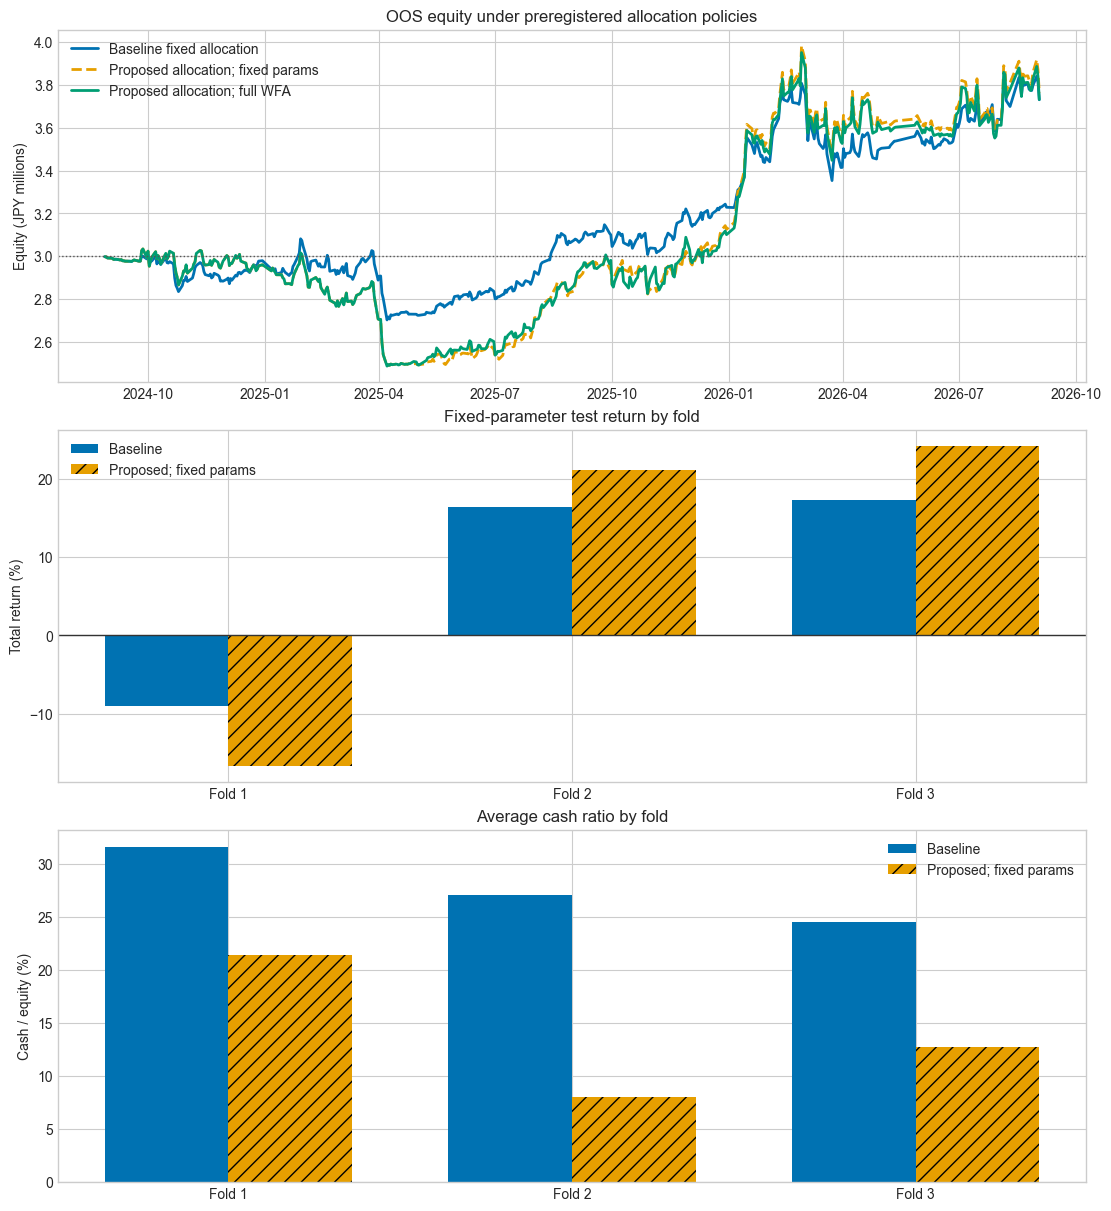

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 12), constrained_layout=True)

for label, frame, color, style in [
    ("Baseline fixed allocation", baseline_fixed["equity"], COLORS["baseline"], "-"),
    ("Proposed allocation; fixed params", proposed_fixed["equity"], COLORS["proposed"], "--"),
    ("Proposed allocation; full WFA", proposed_wfa["equity"], COLORS["proposed_wfa"], "-"),
]:
    axes[0].plot(
        frame["date"],
        frame["equity"] / 1_000_000,
        label=label,
        color=color,
        linestyle=style,
        linewidth=2,
    )
axes[0].axhline(3.0, color="#555555", linewidth=1, linestyle=":")
axes[0].set_title("OOS equity under preregistered allocation policies")
axes[0].set_ylabel("Equity (JPY millions)")
axes[0].legend(frameon=False)

x = np.arange(len(fold_comparison))
width = 0.36
axes[1].bar(
    x - width / 2,
    fold_comparison["total_return_baseline"] * 100,
    width,
    label="Baseline",
    color=COLORS["baseline"],
)
axes[1].bar(
    x + width / 2,
    fold_comparison["total_return_proposed"] * 100,
    width,
    label="Proposed; fixed params",
    color=COLORS["proposed"],
    hatch="//",
)
axes[1].axhline(0, color="#333333", linewidth=1)
axes[1].set_xticks(x, [f"Fold {fold}" for fold in fold_comparison["fold"]])
axes[1].set_title("Fixed-parameter test return by fold")
axes[1].set_ylabel("Total return (%)")
axes[1].legend(frameon=False)

axes[2].bar(
    x - width / 2,
    fold_comparison["average_cash_ratio_baseline"] * 100,
    width,
    label="Baseline",
    color=COLORS["baseline"],
)
axes[2].bar(
    x + width / 2,
    fold_comparison["average_cash_ratio_proposed"] * 100,
    width,
    label="Proposed; fixed params",
    color=COLORS["proposed"],
    hatch="//",
)
axes[2].set_xticks(x, [f"Fold {fold}" for fold in fold_comparison["fold"]])
axes[2].set_title("Average cash ratio by fold")
axes[2].set_ylabel("Cash / equity (%)")
axes[2].legend(frameon=False)

display(
    fig,
    metadata={
        "image/png": {
            "alt": (
                "Three-panel comparison of OOS equity, fixed-parameter fold returns, "
                "and average cash ratios for baseline and preregistered allocation policies."
            )
        }
    },
)
plt.close(fig)

## Takeaways

In [9]:
folds_improved = int(fold_comparison["return_improved"].sum())
baseline_cash = float(baseline_fixed["folds"]["average_cash_ratio"].mean())
proposed_cash = float(proposed_fixed["folds"]["average_cash_ratio"].mean())
proposed_wfa_summary = proposed_wfa["summary"]
decision = "採用条件をすべて通過" if adopt_proposed_policy else "採用条件を満たさず"

display(
    Markdown(
        f"""
1. **主比較:** 固定パラメータのCAGRは
   **{baseline_fixed['summary']['cagr']:.2%} → {proposed_fixed['summary']['cagr']:.2%}**、
   最大ドローダウンは **{baseline_fixed['summary']['max_drawdown']:.2%} → {proposed_fixed['summary']['max_drawdown']:.2%}**。
2. **fold一貫性:** 収益率が改善したのは **{folds_improved}/3 fold**。
3. **現金滞留:** fold平均現金比率の単純平均は
   **{baseline_cash:.2%} → {proposed_cash:.2%}**。
4. **完全WFA:** 提案方式のCAGRは **{proposed_wfa_summary['cagr']:.2%}**、
   最大ドローダウンは **{proposed_wfa_summary['max_drawdown']:.2%}**。
   CAGR 15%は **{'通過' if proposed_wfa_summary['cagr'] >= TARGET_CAGR else '未達'}**、
   最大ドローダウン-20%は **{'通過' if proposed_wfa_summary['max_drawdown'] >= TARGET_MAX_DRAWDOWN else '未達'}**。

**事前登録判定:** `remaining-slots-capped`は**{decision}**。
判定に失敗した場合は`fixed-equal-weight`を既定のまま維持し、同じOOS結果を見て10%上限を調整しない。
"""
    )
)


1. **主比較:** 固定パラメータのCAGRは
   **11.44% → 11.90%**、
   最大ドローダウンは **-12.29% → -18.02%**。
2. **fold一貫性:** 収益率が改善したのは **2/3 fold**。
3. **現金滞留:** fold平均現金比率の単純平均は
   **27.74% → 14.09%**。
4. **完全WFA:** 提案方式のCAGRは **11.46%**、
   最大ドローダウンは **-18.02%**。
   CAGR 15%は **未達**、
   最大ドローダウン-20%は **通過**。

**事前登録判定:** `remaining-slots-capped`は**採用条件をすべて通過**。
判定に失敗した場合は`fixed-equal-weight`を既定のまま維持し、同じOOS結果を見て10%上限を調整しない。


### Caveats

- 現在の`fundamentals.scalecat`を過去にも適用するサバイバーシップ・バイアスが残る。
- 約2年・3foldの比較であり、相場局面をまたぐ恒常的な優位性を確立するものではない。
- 10%は事前固定の設計上限で、統計的に推定した最適値ではない。
- 新規取得時の上限であり、値上がり後のポジション比率は制御していない。